# LangGraph Basics - Building a Simple Math Agent

## Step 1: Import dependencies and initialize the LLM

In [20]:
import os
import getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"var: ")

_set_env("OPENAI_API_KEY")

In [21]:
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "openai:gpt-5-mini",
)

## Step 2: Define tools for arithmetic operations

In [4]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

## Step 3: Bind tools to the LLM

In [22]:
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [23]:
output_function_call = llm_with_tools.invoke("Add 3 and 4 using the add tool")
output_function_call

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 195, 'total_tokens': 285, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DfRuXyehOSchHsLB2Y43Vd3CQIS8I', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2705-241f-7162-a8e3-65c239e0667b-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_ZzDvtLkBHmhTj8uAfTGhnN2Q', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 195, 'output_tokens': 90, 'total_tokens': 285, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

In [28]:
output_function_call.tool_calls

[{'name': 'add',
  'args': {'a': 3, 'b': 4},
  'id': 'call_ZzDvtLkBHmhTj8uAfTGhnN2Q',
  'type': 'tool_call'}]

In [29]:
output_function_call.tool_calls[0]["args"]

{'a': 3, 'b': 4}

## Step 4: Define the agent state

In [30]:
# from langgraph.graph import MessagesState
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

## Step 5: Define the LLM node

In [31]:
from langchain_core.messages import SystemMessage

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }

## Step 6: Define the tool execution node

In [32]:
from langchain_core.messages import ToolMessage

def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

## Step 7: Define the conditional routing logic

In [33]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

def route_between_nodes(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"
    # Otherwise, we stop (reply to the user)
    return END

## Step 8: Build the agent graph

In [34]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    route_between_nodes,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

## Step 9: Visualize the agent graph

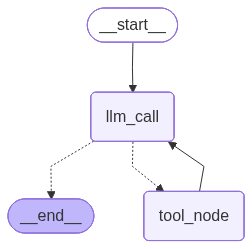

In [35]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

## Step 10: Run the agent with a sample query

In [36]:
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content="Multiply 200 by 2 then \
    divide the result by 100")]
messages = agent.invoke({"messages": messages})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 200 by 2 then     divide the result by 100
================================== Ai Message ==================================
Tool Calls:
  multiply (call_V2RJvNjquB685sV2iXaOMLu5)
 Call ID: call_V2RJvNjquB685sV2iXaOMLu5
  Args:
    a: 200
    b: 2
================================= Tool Message =================================

400
================================== Ai Message ==================================
Tool Calls:
  divide (call_pIbsqge8q1TmNOLHYHoSlQlR)
 Call ID: call_pIbsqge8q1TmNOLHYHoSlQlR
  Args:
    a: 400
    b: 100
================================= Tool Message =================================

4.0
================================== Ai Message ==================================

4.0


In [40]:
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Adds a and b."""
    return a + b

llm = init_chat_model(
    "openai:gpt-5.4-mini")

addition_agent = create_agent(
    model=llm,
    tools=[add])

addition_agent.invoke({"messages": [HumanMessage(content="Add 3 and 4.")]})

{'messages': [HumanMessage(content='Add 3 and 4.', additional_kwargs={}, response_metadata={}, id='1e4519d5-e6b3-45a1-b675-9a11b07a9110'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 133, 'total_tokens': 153, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DfRzT1oOcDfQH0IS2ZCjRmdOXtT4z', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2709-cf2d-7482-83bd-719534fdeb32-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_mhnBzM7DIKFINEv5S2l1koTU', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 133, 'output_tokens': 20, 'total_tokens': 153

In [41]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies a and b."""
    return a * b

multiplication_agent = create_agent(
    model=llm,
    tools=[multiply],
)

multiplication_agent.invoke({"messages": [HumanMessage(content="Multiply 200 by 2")]})

{'messages': [HumanMessage(content='Multiply 200 by 2', additional_kwargs={}, response_metadata={}, id='0828ae97-892c-4379-8991-638feab6b239'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 134, 'total_tokens': 154, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DfRzcS3qaHJA6NPsFGv82IzFvw8bc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e2709-f3f9-74b1-a73f-ff87f5971f2d-0', tool_calls=[{'name': 'multiply', 'args': {'a': 200, 'b': 2}, 'id': 'call_Ip5Ze5lUdXvik5FfvYIFwAAG', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 134, 'output_tokens': 20, 'total_

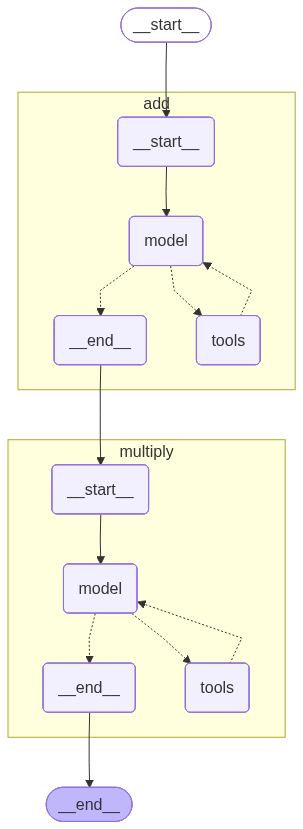

In [42]:
from mailbox import Message
from IPython.display import Image
from langgraph.graph import StateGraph, END, MessagesState

# Define a simple state class to hold the running value
class CalcState(MessagesState):
    pass
    

# Node for add agent
def add_node(state: CalcState):
    # expects state["messages"] to be present
    result = addition_agent.invoke({"messages": state["messages"]})
    # get the output value from the agent's response
    # The agent returns a list of messages, the last one is the AIMessage
    # For this example, let's extract the tool call result from the message
    # We'll just pass the messages along for the next agent
    return {"messages": result["messages"]}

# Node for multiply agent
def multiply_node(state: CalcState):
    result = multiplication_agent.invoke({"messages": state["messages"]})
    return {"messages": result["messages"]}

# Build the graph
graph = StateGraph(CalcState)
graph.add_node("add", add_node)
graph.add_node("multiply", multiply_node)

# For this example, let's go from add -> multiply -> END
graph.add_edge("add", "multiply")
graph.add_edge("multiply", END)

# Set the entry point
graph.set_entry_point("add")

# Compile the graph
compiled_graph = graph.compile()

Image(compiled_graph.get_graph(xray=True).draw_mermaid_png())

In [43]:
compiled_graph.invoke({"messages": [HumanMessage(content="Add 12 and 5, then multiply the result by 8. Then subtract 5, then multiply everything by 23")]} )

{'messages': [HumanMessage(content='Add 12 and 5, then multiply the result by 8. Then subtract 5, then multiply everything by 23', additional_kwargs={}, response_metadata={}, id='a66f031c-a832-4983-86a7-4c4a800893b5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 152, 'total_tokens': 205, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DfS0fdZQKpc7sVKRbDqzPUtn66E5p', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e270a-f0c7-7162-bc01-f79557afda21-0', tool_calls=[{'name': 'add', 'args': {'a': 12, 'b': 5}, 'id': 'call_waXuVT7yoz4wEzw81G0kP9EP', 'type': 'tool_call'}, {'name': 'add', 'arg

# what are the metrics/tools to monitor the LLM and agents in term of performance?latency-accurency...

- Tokens used

In [44]:
output = compiled_graph.invoke({"messages": [HumanMessage(content="Add 12 and 5 and multiply everything by 23")]})

output

{'messages': [HumanMessage(content='Add 12 and 5 and multiply everything by 23', additional_kwargs={}, response_metadata={}, id='7d6b82ef-7334-4dc5-96be-deeb444f61e3'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 138, 'total_tokens': 158, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DfS5U0Ot8OrADDFxbh4f2oWi0DrLg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e270f-7f17-7911-ad83-2fd503552e24-0', tool_calls=[{'name': 'add', 'args': {'a': 12, 'b': 5}, 'id': 'call_MoGtpkxB5Ccsi5o3UmSvitSK', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 138, 'output_t

In [46]:
token_count = 0
for msg in output["messages"]:
    try:
        token_count+=msg.response_metadata["token_usage"]["total_tokens"]
    except:
        pass

print(f"Total tokens used: {token_count}")

Total tokens used: 553


In [49]:
# this is an imaginary number for what the total price / M tokens would cost
print(f"Total cost: {token_count * 0.0000002} dollars")

Total cost: 0.00011059999999999999 dollars


- Latency

In [50]:
import time

start = time.time()
output = compiled_graph.invoke({"messages": [HumanMessage(content="Add 12 and 5 and multiply everything by 23")]})
end = time.time()
print(f"Time taken: {end - start} seconds")

Time taken: 3.1816811561584473 seconds


- quality of responses

In [ ]:
# scores between 1-5
# eval_llm_score = llm_eval.evaluates(output)
# sample mock!